# 02 · Route each request and reveal right-fit models

*Can one endpoint serve the whole travel workload — and can we see which model answered?*

Notebook 01 held the model fixed and moved the instructions. Here we do the opposite:
we fix good instructions and move the **model** — by pointing one agent at the
`model-router` deployment. The router picks an underlying model per request, and we
read `response.model` to see its choice. Benchmarking across task classes turns that
into a **right-fit reveal**: cheap models for easy tasks, stronger models where the
work is hard — without us hand-routing anything.

```mermaid
flowchart LR
    A[Create decomposition agent<br/>model-router default] --> B[Benchmark across task classes]
    B --> C[Read response.model<br/>per request]
    C --> D[Right-fit reveal<br/>model chosen by task]
    D --> E[Compare vs fixed baselines<br/>cheap · frontier]
    E --> F{Router near frontier quality<br/>at lower cost?}
    F -->|yes| Keep[Adopt router as default]
    F -->|no| Next[Tune modes in 03]
```

## 1. Install dependencies and load config

Same one-time gate as the other notebooks: ensure packages, then load the local `.env`.

In [1]:
## 1. Ensure dependencies and read .env
import importlib.util, subprocess, sys

_needed = {
    "azure-ai-projects": "azure.ai.projects",
    "azure-identity": "azure.identity",
    "openai": "openai",
    "python-dotenv": "dotenv",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
_missing = [pkg for pkg, mod in _needed.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print("Installing:", ", ".join(_missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *_missing])
else:
    print("All dependencies present.")

from dotenv import load_dotenv
load_dotenv(".env")
print(".env loaded from this folder (if present).")

All dependencies present.
.env loaded from this folder (if present).


## 2. Authenticate and open the project

Entra ID auth (`az login`) and the `contoso-travel-releases` project. We print only
whether each variable is set.

In [2]:
## 2. Project client + config check
import os
from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient

REQUIRED = [
    "MICROSOFT_FOUNDRY_ENDPOINT",
    "AZURE_MODEL_ROUTER_DEPLOYMENT",
    "AZURE_DECOMPOSITION_AGENT_NAME",
]
OPTIONAL = ["AZURE_BASELINE_CHEAP_DEPLOYMENT", "AZURE_FRONTIER_DEPLOYMENT"]
for name in REQUIRED:
    print(f"{name:<34} {'OK' if os.getenv(name) else 'MISSING'}")
for name in OPTIONAL:
    print(f"{name:<34} {'OK' if os.getenv(name) else 'skip (baseline compare off)'}")
if not all(os.getenv(n) for n in REQUIRED):
    raise SystemExit("Fill the missing variables in .env (copy from sample.env) and re-run.")

endpoint = os.environ["MICROSOFT_FOUNDRY_ENDPOINT"]
credential = DefaultAzureCredential()
project = AIProjectClient(endpoint=endpoint, credential=credential)
print("Project client ready.")

MICROSOFT_FOUNDRY_ENDPOINT         OK
AZURE_MODEL_ROUTER_DEPLOYMENT      OK
AZURE_DECOMPOSITION_AGENT_NAME     OK
AZURE_BASELINE_CHEAP_DEPLOYMENT    OK
AZURE_FRONTIER_DEPLOYMENT          OK
Project client ready.


## 3. Create the decomposition agent on `model-router`

We create `contoso-travel-decomposition` with its model set to the **`model-router`**
deployment — so every request is routed — and give it solid
[`02-policy-aware`](../../../demos/contoso-travel/instructions/02-policy-aware.md)
instructions so the answers are good and the routing is what varies. Creation is
idempotent.

**Reuse the index.** Attach the same Knowledge files from notebook 00 (Agents →
`contoso-travel-decomposition` → Knowledge) so the agent answers from the Contoso
catalog. The benchmark runs without it, but grounding makes the per-task picks realistic.

In [3]:
## 3. Create (or reuse) the decomposition agent
from pathlib import Path
from azure.ai.projects.models import PromptAgentDefinition

decomp_agent = os.environ["AZURE_DECOMPOSITION_AGENT_NAME"]
router_deployment = os.environ["AZURE_MODEL_ROUTER_DEPLOYMENT"]

def _load_instructions(rung: str) -> str:
    raw = Path(f"../../../demos/contoso-travel/instructions/{rung}").read_text(encoding="utf-8")
    return raw.split("-->", 1)[-1].strip() if raw.lstrip().startswith("<!--") else raw

try:
    agent = project.agents.get(decomp_agent)
    print(f"Agent '{decomp_agent}' already exists (version {agent.version}) — reusing it.")
except Exception:
    agent = project.agents.create_version(
        agent_name=decomp_agent,
        definition=PromptAgentDefinition(
            model=router_deployment,
            instructions=_load_instructions("02-policy-aware.md"),
        ),
    )
    print(f"Agent '{decomp_agent}' created (version {agent.version}) on {router_deployment}.")

Agent 'contoso-travel-decomposition' created (version 1) on model-router.


## 4. Scoring toolkit

We reuse the shared [Contoso benchmark](../../../demos/contoso-travel/benchmark/) and its
deterministic grader so the workload matches every other rung. `run_suite` records the
model the router chose (`response.model`), latency, tokens, and pass/fail per query.

In [4]:
## 4. Scoring toolkit (shared shape with notebook 01)
import sys, time
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../../../demos/contoso-travel/benchmark").resolve()))
from run_benchmark import load_json, grade  # noqa: E402

BENCH = Path("../../../demos/contoso-travel/benchmark")
QUERIES = load_json(BENCH / "queries.json")["queries"]

def make_agent_caller(agent_name: str):
    """Route through a prompt agent (its model is the model-router deployment)."""
    client = project.get_openai_client(agent_name=agent_name)
    def ask(turns):
        conv = client.conversations.create().id
        text = model = ""; tin = tout = 0
        for turn in turns:
            resp = client.responses.create(conversation=conv, input=turn)
            text = resp.output_text
            model = getattr(resp, "model", "") or model
            u = getattr(resp, "usage", None)
            if u:
                tin += getattr(u, "input_tokens", 0) or 0
                tout += getattr(u, "output_tokens", 0) or 0
        return text, model, tin, tout
    return ask

def make_model_caller(deployment: str):
    """Call a fixed deployment directly (no agent) for a baseline reference."""
    client = project.get_openai_client()
    def ask(turns):
        conv = client.conversations.create().id
        text = model = ""; tin = tout = 0
        for turn in turns:
            resp = client.responses.create(conversation=conv, input=turn, model=deployment)
            text = resp.output_text
            model = getattr(resp, "model", "") or deployment
            u = getattr(resp, "usage", None)
            if u:
                tin += getattr(u, "input_tokens", 0) or 0
                tout += getattr(u, "output_tokens", 0) or 0
        return text, model, tin, tout
    return ask

def run_suite(ask, label, queries=QUERIES, limit=None) -> pd.DataFrame:
    rows = []
    for q in (queries[:limit] if limit else queries):
        turns = q.get("turns") or [q["query"]]
        start = time.perf_counter()
        try:
            text, model, tin, tout = ask(turns)
        except Exception as exc:
            text, model, tin, tout = f"ERROR: {exc}", "", 0, 0
        passed, _ = grade(q, text)
        rows.append({
            "run": label, "id": q["id"], "category": q["category"], "gate": q["gate"],
            "model": model or "-", "passed": passed,
            "latency_ms": round((time.perf_counter() - start) * 1000),
            "tokens_in": tin, "tokens_out": tout,
        })
    return pd.DataFrame(rows)

## 5. Benchmark the router across the workload

One pass over every query, routed. We read the headline scorecard first — quality,
policy accuracy, latency, and tokens — then dig into *which* model answered.

In [5]:
## 5. Run the routed benchmark
if "make_agent_caller" not in globals():
    raise SystemExit("Run sections 1-4 first (they define the client and scoring toolkit). Tip: Run All.")

ask_router = make_agent_caller(decomp_agent)
df_router = run_suite(ask_router, "router")

q = 100 * df_router["passed"].mean()
pol = df_router[df_router["gate"] == "policy"]
print("Router scorecard")
print(f"  Quality           {q:.1f}%")
print(f"  Policy accuracy   {100 * pol['passed'].mean():.1f}%")
print(f"  Latency p50/p95   {df_router['latency_ms'].median():.0f} / {df_router['latency_ms'].quantile(0.95):.0f} ms")
print(f"  Tokens in/out     {df_router['tokens_in'].sum()} / {df_router['tokens_out'].sum()}")
df_router.head()

Router scorecard
  Quality           46.7%
  Policy accuracy   26.7%
  Latency p50/p95   4254 / 8681 ms
  Tokens in/out     13017 / 8857


,run,id,category,gate,model,passed,latency_ms,tokens_in,tokens_out
0,router,Q01,faq,policy-knowledge,gpt-5.6-luna-2026-07-09,True,4065,368,38
1,router,Q02,faq,policy-knowledge,gpt-5.6-luna-2026-07-09,False,2843,365,108
2,router,Q03,faq,policy-knowledge,gpt-5.6-luna-2026-07-09,True,4531,368,197
3,router,Q04,faq,policy-knowledge,gpt-5-mini-2025-08-07,True,8787,367,1072
4,router,Q05,search,grounding,gpt-5.6-luna-2026-07-09,True,3890,367,239


## 6. Which model did the router pick per task?

This is the decomposition insight: the router quietly **right-sizes** the model to the
task. Easy classes (classification, lookups) should land on cheaper models; harder
classes (multi-step reasoning, policy exceptions) should pull a stronger one. The
cross-tab and stacked bar show the split.

model,gpt-5-mini-2025-08-07,gpt-5.6-luna-2026-07-09,gpt-5.6-terra-2026-07-09
category,,,
adversarial,0,3,0
exception,0,3,0
faq,1,3,0
multi-turn,0,2,0
planning,0,2,0
policy,1,5,0
search,0,5,1
synthesis,0,2,0
transaction,0,2,0


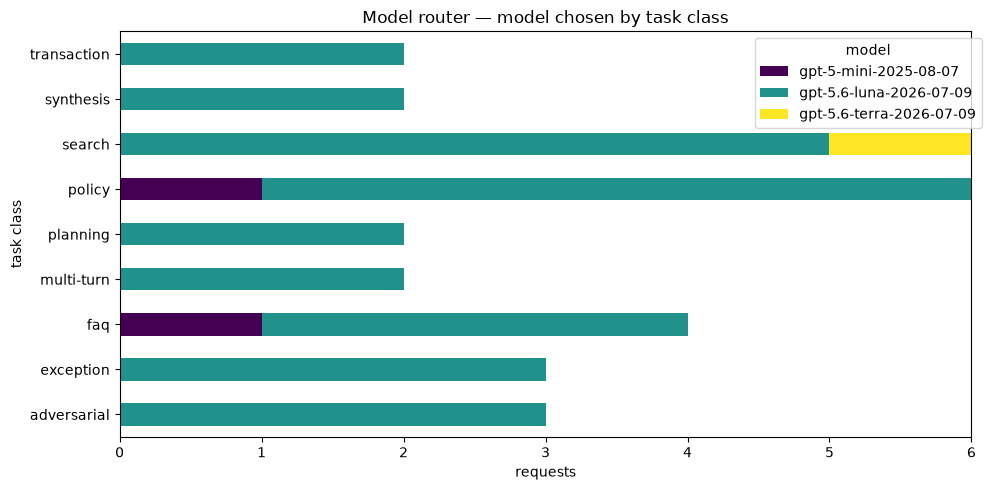

In [6]:
## 6. Right-fit reveal — model chosen by task class
mix = pd.crosstab(df_router["category"], df_router["model"])
display(mix)
mix.plot.barh(stacked=True, figsize=(10, 5), colormap="viridis")
plt.title("Model router — model chosen by task class")
plt.xlabel("requests"); plt.ylabel("task class"); plt.legend(title="model", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

## 7. Compare against fixed models — fairly, on verbosity *and* cost

Is routing a good trade? We run the same benchmark on **fixed** cheap and frontier
deployments — but through prompt agents with the **same `02-policy-aware` instructions**
as the router agent, so quality reflects the *model*, not the presence of instructions
(a bare model call would fail our grounded grader no matter how strong the model is).

We separate two things people conflate:

- **Verbosity** — average **output tokens** per answer. A cheaper model often *generates
  more* (it hedges and repeats); a frontier model is usually terser.
- **Cost** — `tokens × price-per-token`, summed. Cheap models cost little *per token*, so
  they can be the cheapest overall even when they're the most verbose.

Prices are pulled **live** from the public [Azure Retail Prices API](https://learn.microsoft.com/en-us/rest/api/cost-management/retail-prices/azure-retail-prices)
(`fetch_token_prices()` — no auth). Models the catalog doesn't list (preview or the
fictional deployments in this demo) fall back to the editable `PLACEHOLDER_PRICES` map.
Set `AZURE_BASELINE_CHEAP_DEPLOYMENT` and `AZURE_FRONTIER_DEPLOYMENT` in `.env` to enable
the fixed baselines.

,quality_pct,avg_tokens,p50_ms
run,,,
cheap-fixed,33.3,296.100000,3429.5
router,46.7,295.233333,4254.5
frontier-fixed,33.3,193.000000,3726.0


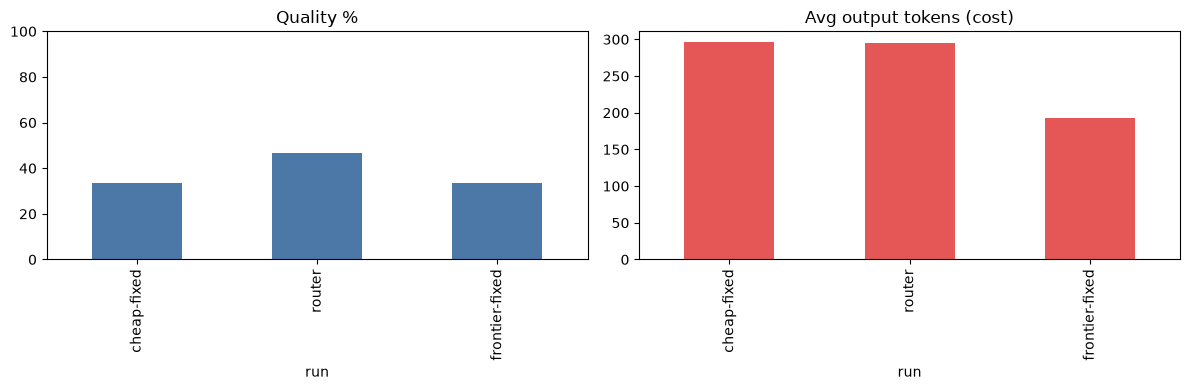

In [ ]:
## 7. Router vs fixed baselines — fair comparison, verbosity AND cost
from azure.ai.projects.models import PromptAgentDefinition

# Fair test: run the cheap and frontier models through prompt agents carrying the SAME
# 02-policy-aware instructions as the router agent. Only the model binding changes, so
# quality reflects the model — not whether instructions were present.
def agent_on(deployment: str, name: str) -> str:
    try:
        project.agents.get(name)
    except Exception:
        project.agents.create_version(
            agent_name=name,
            definition=PromptAgentDefinition(
                model=deployment, instructions=_load_instructions("02-policy-aware.md"),
            ),
        )
    return name

frames = [df_router]
cheap = os.getenv("AZURE_BASELINE_CHEAP_DEPLOYMENT")
frontier = os.getenv("AZURE_FRONTIER_DEPLOYMENT")
if cheap:
    frames.append(run_suite(make_agent_caller(agent_on(cheap, f"{decomp_agent}-cheap")), "cheap-fixed"))
if frontier:
    frames.append(run_suite(make_agent_caller(agent_on(frontier, f"{decomp_agent}-frontier")), "frontier-fixed"))

allruns = pd.concat(frames, ignore_index=True)

# --- Pricing: pull live rates from the public Azure Retail Prices API, fall back to placeholders ---
import json as _json
from urllib.request import urlopen
from urllib.parse import quote

# Fallback USD per 1M tokens for models the live catalog doesn't list (preview / fictional
# deployments in this demo). Live rates for real models overwrite these. Edit freely.
PLACEHOLDER_PRICES = {
    "gpt-5.4-nano": {"in": 0.05, "out": 0.20},
    "gpt-5.4-mini": {"in": 0.15, "out": 0.60},
    "gpt-5.4":      {"in": 1.00, "out": 4.00},
    "gpt-5.6":      {"in": 1.25, "out": 5.00},
}
DEFAULT_PRICE = {"in": 0.50, "out": 2.00}

def fetch_token_prices(currency="USD") -> dict:
    """Pull per-1M-token text prices from https://prices.azure.com (service 'Foundry Models',
    no auth). Returns {family: {'in': usd, 'out': usd}} for plain global text meters — e.g.
    'gpt-4o-mini' -> {'in': 0.15, 'out': 0.6}. Never raises; returns {} offline."""
    flt = ("serviceName eq 'Foundry Models' and priceType eq 'Consumption' "
           "and contains(meterName,'Token')")
    url = f"https://prices.azure.com/api/retail/prices?currencyCode='{currency}'&$filter={quote(flt)}"
    SKIP = ("aud", "tts", "transcribe", "realtime", "cach", "batch", "spec", "-dz", "img", "image", "embed")
    DROP = {"inp", "outp", "input", "output", "glbl", "regnl", "dz", "global",
            "regional", "datazone", "txt", "tokens"}
    def family(first: str) -> str:  # 'gpt-4o-mini-0718-inp-glbl' -> 'gpt-4o-mini'
        return "-".join(p for p in first.split("-")
                        if p not in DROP and not (p.isdigit() and len(p) == 4))
    found, pages = {}, 0
    try:
        while url and pages < 30:
            with urlopen(url, timeout=20) as resp:
                data = _json.loads(resp.read().decode())
            pages += 1
            for it in data.get("Items", []):
                meter = (it.get("meterName") or "").lower()
                if any(s in meter for s in SKIP) or "glbl" not in meter:  # plain global text meters only
                    continue
                unit = it.get("unitOfMeasure") or ""
                per_1m = (it.get("unitPrice") or 0.0) * (1000 if "1k" in unit.lower() else 1)
                slot = found.setdefault(family(meter.split(" ")[0]), {})
                if "inp" in meter or "input" in meter:
                    slot.setdefault("in", round(per_1m, 4))
                elif "outp" in meter or "output" in meter:
                    slot.setdefault("out", round(per_1m, 4))
            url = data.get("NextPageLink")
    except Exception as exc:  # offline / API change — degrade to placeholders
        print("Live pricing unavailable, using placeholders:", type(exc).__name__, exc)
    return {k: v for k, v in found.items() if "in" in v and "out" in v}

_live = fetch_token_prices()
PRICES = {**PLACEHOLDER_PRICES, **_live}
print(f"Loaded {len(_live)} live model prices; total map has {len(PRICES)} entries.")

def price_for(model: str) -> dict:
    # Longest-prefix match so 'gpt-4o-mini-2024-07-18' prefers 'gpt-4o-mini' over 'gpt-4o'.
    hits = [(k, p) for k, p in PRICES.items() if model.startswith(k)]
    return max(hits, key=lambda kp: len(kp[0]))[1] if hits else DEFAULT_PRICE

allruns["cost_usd"] = allruns.apply(
    lambda r: r["tokens_in"] / 1e6 * price_for(r["model"])["in"]
    + r["tokens_out"] / 1e6 * price_for(r["model"])["out"], axis=1)

# Per run: quality, verbosity (avg output tokens), true cost (Σ tokens × price), latency.
order = [r for r in ["cheap-fixed", "router", "frontier-fixed"] if r in set(allruns["run"])]
summary = allruns.groupby("run").agg(
    quality_pct=("passed", lambda s: round(100 * s.mean(), 1)),
    avg_out_tokens=("tokens_out", "mean"),
    total_cost_usd=("cost_usd", "sum"),
    p50_ms=("latency_ms", "median"),
).reindex(order)
display(summary.round({"avg_out_tokens": 0, "total_cost_usd": 4}))

# Per model: verbosity vs unit cost — shows why a "cheap" model can still be pricey if it
# rambles, and how the router's model mix nets out.
per_model = allruns.groupby("model").agg(
    calls=("id", "count"),
    avg_out_tokens=("tokens_out", "mean"),
    avg_cost_usd=("cost_usd", "mean"),
).sort_values("avg_cost_usd")
display(per_model.round({"avg_out_tokens": 0, "avg_cost_usd": 5}))

if len(summary) > 1:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    summary["quality_pct"].plot.bar(ax=ax[0], color="#4C78A8", title="Quality %"); ax[0].set_ylim(0, 100)
    summary["avg_out_tokens"].plot.bar(ax=ax[1], color="#F58518", title="Verbosity — avg output tokens")
    summary["total_cost_usd"].plot.bar(ax=ax[2], color="#E45756", title="Estimated cost (USD = tokens x price)")
    for a in ax:
        a.set_xlabel("")
    plt.tight_layout(); plt.show()

    per_model[["avg_out_tokens", "avg_cost_usd"]].plot.bar(
        subplots=True, layout=(1, 2), figsize=(14, 4), legend=False, color=["#F58518", "#E45756"],
        title=["Verbosity by model (avg output tokens)", "Unit cost by model (avg USD/call)"])
    plt.tight_layout(); plt.show()

### Reading the numbers

- **Verbosity ≠ cost.** A high `avg_out_tokens` for the cheap model with a still-low
  `total_cost_usd` is exactly the point — per-token *price* dominates, not token *count*.
  The interesting cases are terse-but-expensive (frontier) vs verbose-but-cheap (nano).
- **Is the router earning its keep?** The win condition is router **quality near the
  frontier** at **cost near the cheap** model. If the router's cost sits close to cheap
  while quality tracks frontier, adopt it as the default — notebook 03 then tunes that
  balance with routing modes.
- **Per-model table = decomposition in dollars.** Models the router sent easy tasks to
  should show low unit cost; models it reserved for hard tasks cost more per call. A
  pricey model doing easy work is a candidate to constrain with a model subset (notebook 04).
- **Small-sample caveat.** With ~30 queries a few flipped rows swing `quality_pct` a lot —
  treat single-digit gaps as noise, and grow `queries.json` for production-like signal.

## 8. Your Turn

- **Read the reveal.** Which task classes did the router send to the cheap model? Do
  those match your intuition about which requests are 'easy'?
- **Find the crossover.** Is there a class where the router picks the frontier but the
  cheap fixed model still passes? That's a candidate to force cheaper later with a subset.
- **Stress a class.** Add a few harder queries to `queries.json` for one category and
  re-run — does the router escalate to a stronger model on exactly those rows?

## 9. Summary

Pointing one agent at `model-router` let a single endpoint serve the whole travel
workload, and `response.model` made the routing **visible**: the router decomposed the
workload and right-sized a model to each task class — tracking frontier quality while
spending closer to the cheap baseline on the easy majority.

That's the default worth adopting. But the router's *balance* between cost and quality
is itself a lever. In **notebook 03** we switch routing **modes** — Cost, Balanced,
Quality — and measure whether Cost mode holds the policy gate while lowering spend, and
whether Quality mode earns its premium. And don't forget **notebook 01**: your optimizer
job should have candidates by now — head back to its section 8 to promote the best
instructions.

## 10. References

- [Use model router with Foundry agents](https://learn.microsoft.com/en-us/azure/foundry/openai/how-to/model-router-agents) — routing behind an agent.
- [Model router concepts](https://learn.microsoft.com/en-us/azure/foundry/openai/concepts/model-router) — how the router selects a model.
- [Evaluate model router for your workload](https://learn.microsoft.com/en-us/azure/foundry/openai/how-to/evaluate-model-router) — the scorecard dimensions.
- [Contoso Travel benchmark](../../../demos/contoso-travel/benchmark/) · [Capsule overview](README.md) · [Glossary](../../../docs/GLOSSARY.md)